In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision import transforms
from torch.utils.data.sampler import SubsetRandomSampler
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import pickle as pkl
import warnings
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
import wandb
from sklearn.metrics import recall_score
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification

if torch.cuda.is_available():
    torch.device('cuda')
    print("Using the GPU!")

tqdm.pandas()

#test hello

/home/tyler_mlboss/anaconda3/envs/ds_beast/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the GPU!


In [2]:
train_df = pd.read_csv('~/data/train_df_clean.csv',index_col=0)
test_df = pd.read_csv('~/data/test_df_clean.csv')
dev_df = pd.read_csv('~/data/dev_df_clean.csv')


print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74724, 6)
(23353, 6)
(18682, 6)


In [3]:
train_df = train_df.dropna().reset_index(drop=True)
dev_df = dev_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)


print(train_df.shape)
print(test_df.shape)
print(dev_df.shape)

(74724, 6)
(23353, 6)
(18682, 6)


In [4]:
train_df.head()

,author,clean_title,id,2_way_label,3_way_label,6_way_label
0,FloopyDoopy,they think they are above the law the firms th...,bgjip0,1,0,0
1,mister10percent,this old kelloggs mug is years old,dl7luu,1,0,0
2,Klyuchak,this molding flash that looks like a butterfly,bu0gal,1,0,0
3,PooYaKasha,these tarmac markings that show where to park ...,bnvxjq,1,0,0
4,ruskeeblue,trump has no one in charge of fema or the noaa...,6w0q7n,1,0,0


In [5]:
def load_col_info_np(df,set_name):
    # ['tot_r','tot_r_sq','tot_g','tot_g_sq','tot_b','tot_b_sq','tot_pixs']
    avg_chan_nps = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/avg_chans'

    loaded_col_inf = np.load(f'{avg_chan_nps}/{set_name}_col_chan_inf.npy')

    df['tot_r'] = loaded_col_inf[:,0]
    df['tot_r_sq'] = loaded_col_inf[:,1]
    
    df['tot_g'] = loaded_col_inf[:,2]
    df['tot_g_sq'] = loaded_col_inf[:,3]
    
    df['tot_b'] = loaded_col_inf[:,4]
    df['tot_b_sq'] = loaded_col_inf[:,5]
    
    df['tot_pixs'] = loaded_col_inf[:,6]

In [6]:
load_col_info_np(train_df,'train')
load_col_info_np(dev_df,'dev')
load_col_info_np(test_df,'test')

In [7]:
train_df.head()

,author,clean_title,id,2_way_label,3_way_label,6_way_label,tot_r,tot_r_sq,tot_g,tot_g_sq,tot_b,tot_b_sq,tot_pixs
0,FloopyDoopy,they think they are above the law the firms th...,bgjip0,1,0,0,5593607.0,9.083280e+08,5519647.0,8.404138e+08,6859379.0,1.110379e+09,53760.0
1,mister10percent,this old kelloggs mug is years old,dl7luu,1,0,0,21110469.0,3.630498e+09,16625485.0,2.364937e+09,12623533.0,1.508875e+09,136320.0
2,Klyuchak,this molding flash that looks like a butterfly,bu0gal,1,0,0,24632838.0,4.761074e+09,21849486.0,3.856335e+09,18930933.0,3.030002e+09,136320.0
3,PooYaKasha,these tarmac markings that show where to park ...,bnvxjq,1,0,0,15292276.0,2.022101e+09,14444930.0,1.856117e+09,14240278.0,1.864549e+09,136320.0
4,ruskeeblue,trump has no one in charge of fema or the noaa...,6w0q7n,1,0,0,7050553.0,1.057966e+09,7156092.0,1.089849e+09,7430076.0,1.174064e+09,51200.0


In [8]:
def calc_mean_chans(df):
    mean_chan_tup = np.zeros(3)

    i = 0
    for chan in ['r','g','b']:
        chan_vals = df[f'tot_{chan}']

        mean_chan_tup[i] = chan_vals.sum()/df['tot_pixs'].sum()

        i += 1

    return mean_chan_tup

def calc_std_chans(df,chan_means):
    i = 0
    

    std_chan_tup = np.zeros(3)

    for chan in ['r','g','b']:
        chan_vals_sq = df[f'tot_{chan}_sq']

        chan_var = (chan_vals_sq.sum()/df['tot_pixs'].sum())-(chan_means[i]**2)

        std_chan_tup[i] = np.sqrt(chan_var)

        i += 1

    return std_chan_tup


In [9]:
train_raw_means = calc_mean_chans(train_df)
dev_raw_means = calc_mean_chans(dev_df)
test_raw_means = calc_mean_chans(test_df)

train_raw_std = calc_std_chans(train_df,train_raw_means)
dev_raw_std = calc_std_chans(dev_df,train_raw_means)
test_raw_std = calc_std_chans(test_df,train_raw_means)


train_adj_mean = train_raw_means/255
dev_adj_mean = dev_raw_means/255
test_adj_mean = test_raw_means/255

train_adj_std = train_raw_std/255
dev_adj_std = dev_raw_std/255
test_adj_std = test_raw_std/255

print(f"Train mean: {train_adj_mean}, std:{train_adj_std}")
print(f"Dev mean: {dev_adj_mean}, std:{dev_adj_std}")
print(f"Test mean: {test_adj_mean}, std:{test_adj_std}")

Train mean: [0.45661377 0.43411035 0.40786523], std:[0.29919911 0.28872922 0.29697153]
Dev mean: [0.45261119 0.4305528  0.40339562], std:[0.29616078 0.2858011  0.29199199]
Test mean: [0.45318004 0.43208229 0.40681247], std:[0.2928699  0.28467298 0.29464008]


In [10]:

class VGG16(nn.Module):
    def __init__(self, num_classes=2):
        super(VGG16, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU())
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(), 
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU())
        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer5 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer6 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU())
        self.layer7 = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer8 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer9 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer10 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.layer11 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer12 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU())
        self.layer13 = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2))
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(7*7*512, 4096),
            nn.ReLU())
        self.fc1 = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU())
        self.fc2= nn.Sequential(
            nn.Linear(4096, num_classes))
        
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.layer5(out)
        out = self.layer6(out)
        out = self.layer7(out)
        out = self.layer8(out)
        out = self.layer9(out)
        out = self.layer10(out)
        out = self.layer11(out)
        out = self.layer12(out)
        out = self.layer13(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc(out)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

In [11]:
# First defining the transform pipline that will be ran on each image
# when loaded.

img_trans = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_adj_mean,std=train_adj_std)
    
])

class Combined_Dataset(Dataset):
    def __init__(self, input_ids, attention_mask, image_ids, labels, set_name):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.attention_mask = torch.tensor(attention_mask, dtype=torch.long)
        self.image_ids = image_ids
        self.labels = labels

        self.transform = img_trans
        self.img_dir = '/home/tyler_mlboss/data'
        self.set_name = set_name

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        input_ids = self.input_ids[idx]
        attention_mask = self.attention_mask[idx]

        img_id = self.image_ids[idx]
        img = Image.open(f"{self.img_dir}/{self.set_name}/{img_id}.jpg").convert("RGB")
        img_tensor = self.transform(img)

        label = self.labels[idx]
        data = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": img_tensor}
        return data,label 

In [12]:
checkpoint_path = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/results/checkpoint-74728'
bert_model = AutoModelForSequenceClassification.from_pretrained(
        checkpoint_path,
        num_labels=2,                  # This MUST match what you trained with
        dtype=torch.float16,     # Forces it to expect the 1080 Ti's fp16 weights
        device_map="auto"              # Automatically figures out the safest way to load it
    )

model_name = "google-bert/bert-base-uncased" 
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2632.89it/s]


In [13]:
model_path = '/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/'
VGG_model = VGG16()

checkpoint = torch.load(model_path+"vgg16_weights_final.pt")

VGG_model.load_state_dict(checkpoint)

<All keys matched successfully>

In [14]:
encodings = tokenizer(
    train_df["clean_title"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

train_df["input_ids"] = encodings["input_ids"]
train_df["attention_mask"] = encodings["attention_mask"]

In [15]:
encodings = tokenizer(
    dev_df["clean_title"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

dev_df["input_ids"] = encodings["input_ids"]
dev_df["attention_mask"] = encodings["attention_mask"]

In [16]:
encodings = tokenizer(
    test_df["clean_title"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=128
)

test_df["input_ids"] = encodings["input_ids"]
test_df["attention_mask"] = encodings["attention_mask"]

In [17]:
train_df_image_ids = list(train_df['id'])
train_df_labs = list(train_df['2_way_label'])
train_df_text_ids = train_df['input_ids']
train_df_text_attention = train_df["attention_mask"]
train_ds = Combined_Dataset(train_df_text_ids,train_df_text_attention,train_df_image_ids,train_df_labs,'train')


dev_df_image_ids = list(dev_df['id'])
dev_df_labs = list(dev_df['2_way_label'])
dev_df_text_ids = dev_df['input_ids']
dev_df_text_attention = train_df["attention_mask"]
dev_ds = Combined_Dataset(dev_df_text_ids,dev_df_text_attention,dev_df_image_ids,dev_df_labs,'dev')

test_df_image_ids = list(test_df['id'])
test_df_labs = list(test_df['2_way_label'])
test_df_text_ids = test_df['input_ids']
test_df_text_attention = test_df["attention_mask"]
test_ds = Combined_Dataset(test_df_text_ids,test_df_text_attention,test_df_image_ids,test_df_labs,'test')

In [18]:
train_df.head()

,author,clean_title,id,2_way_label,3_way_label,6_way_label,tot_r,tot_r_sq,tot_g,tot_g_sq,tot_b,tot_b_sq,tot_pixs,input_ids,attention_mask
0,FloopyDoopy,they think they are above the law the firms th...,bgjip0,1,0,0,5593607.0,9.083280e+08,5519647.0,8.404138e+08,6859379.0,1.110379e+09,53760.0,"[101, 2027, 2228, 2027, 2024, 2682, 1996, 2375...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,mister10percent,this old kelloggs mug is years old,dl7luu,1,0,0,21110469.0,3.630498e+09,16625485.0,2.364937e+09,12623533.0,1.508875e+09,136320.0,"[101, 2023, 2214, 26129, 2015, 14757, 2003, 20...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
2,Klyuchak,this molding flash that looks like a butterfly,bu0gal,1,0,0,24632838.0,4.761074e+09,21849486.0,3.856335e+09,18930933.0,3.030002e+09,136320.0,"[101, 2023, 18282, 2075, 5956, 2008, 3504, 206...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, ..."
3,PooYaKasha,these tarmac markings that show where to park ...,bnvxjq,1,0,0,15292276.0,2.022101e+09,14444930.0,1.856117e+09,14240278.0,1.864549e+09,136320.0,"[101, 2122, 16985, 22911, 13967, 2008, 2265, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,ruskeeblue,trump has no one in charge of fema or the noaa...,6w0q7n,1,0,0,7050553.0,1.057966e+09,7156092.0,1.089849e+09,7430076.0,1.174064e+09,51200.0,"[101, 8398, 2038, 2053, 2028, 1999, 3715, 1997...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [19]:
import torch
import torch.nn as nn
from safetensors.torch import load_model

class FusionModel(nn.Module):
    def __init__(self, image_model, text_model, dim_a, dim_b, hidden_dim, num_classes=2):
        super().__init__()
        
        # 1. Attach the pre-trained models
        self.image_model = image_model
        self.text_model = text_model
        
        # OPTIONAL: Freeze the base models if you only want to train the new FFNN
        for param in self.image_model.parameters():
            param.requires_grad = False
        for param in self.text_model.parameters():
            param.requires_grad = False

        # 2. Define the new FFNN and Final Linear Layer
        # Because we will concatenate the outputs, the input dimension is dim_a + dim_b
        combined_dim = dim_a + dim_b
        
        self.ffnn = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2), # Good practice to prevent the new head from overfitting
            nn.Linear(hidden_dim, num_classes) # Final linear layer
        )

    def forward(self, x):
        # 3. Flow the input through both base models
        # (Assuming both models accept the exact same input tensor format)
        image_out = self.image_model(x["image"])
        text_out = self.text_model(input_ids=x["input_ids"],attention_mask=x["attention_mask"]).logits
        
        # 4. Combine the outputs
        # We concatenate along the feature dimension (dim=1)
        # Assuming shape is [batch_size, features]
        combined_features = torch.cat((image_out, text_out), dim=1)
        
        # 5. Flow the combined tensor through the FFNN
        final_output = self.ffnn(combined_features)
        
        return final_output

In [20]:
num_epochs = 20
batch_size = 16
learning_rate = 0.005
device = torch.device('cuda')

model = FusionModel(VGG_model,bert_model,2,2,3).to(device)

loss_calc = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay = 0.005, momentum = 0.9) 

train_dl = DataLoader(train_ds,shuffle=True,batch_size=batch_size)
dev_dl = DataLoader(dev_ds,shuffle=True,batch_size=batch_size)
test_dl = DataLoader(test_ds,shuffle=True,batch_size=batch_size)

In [21]:
run = wandb.init(
    project="CSC480-Combined-Model-Project",
    config={
        "learning_rate": learning_rate,
        "architecture": "Combined_model",
        "dataset": "Custom-V2",
        "epochs": num_epochs,
    }
)

# Now start the training loop
for epoch in range(run.config.epochs):

    model.train()

    train_loss = 0
    epoch_train_loss = 0
    
    
    for batch_ind, (data, labs) in enumerate(train_dl):

        data = {k: v.to(device) for k, v in data.items()}
        labs = labs.to(device)

        # Foward
        outputs = model(data)
        loss = loss_calc(outputs,labs)

        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss = loss.item()
        epoch_train_loss += train_loss

        if batch_ind % 50 == 0:
            run.log({'batch_loss':train_loss})

    model.eval()
    pred_labs = []
    correct_labs = []
    
    with torch.no_grad():

        for data,labs in dev_dl:

            data = {k: v.to(device) for k, v in data.items()}
            labs = labs.to(device)

            
            outputs = model(data)
            pred = torch.argmax(outputs.data,dim=1)

            correct_labs.extend(labs.cpu().numpy())
            pred_labs.extend(pred.cpu().numpy())

            # Make a clean slate
            del data,labs,outputs


    # Now checkpointing
    avg_loss = epoch_train_loss/len(train_dl)
    val_rec = recall_score(correct_labs,pred_labs,zero_division=0)
    run.log({'epoch_val_recall':val_rec,'avg_train_loss':avg_loss,'epoch':epoch})


    checkpoint = {
        'epoch':epoch,
        'model_state_dict':model.state_dict(),
        'optimizer_state_dict':optimizer.state_dict()
    }

    torch.save(checkpoint,f"/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/comb_mod_v1_check/com_mod_checkpt{epoch}.pt")

torch.save(model.state_dict(), "/home/tyler_mlboss/drive_1tb/spring_2026/CSC480/CSC_480_Project_Pratt-Garfield/vgg16_checpoints/comb_mod_weights_final.pt")
run.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/tyler_mlboss/.netrc.
wandb: Currently logged in as: tyleraarong (tyleraarong-university-of-arizona) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


avg_train_loss,█▆▆▆▆▆▃▂▂▂▂▂▁▂▂▂▂▁▂▁
batch_loss,▆▄▄▃▃▂▅▆█▅▅▅▄▂▄▄▃▂▅▂▄▂▁▄▄▂▄▇▂▃▅▃▅▄▅▄▄▅▄▂
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
epoch_val_recall,█▇▆▃▄▇▇▅▅▅▆▁▅▅▅▅▇▄▇▇
avg_train_loss,0.41809
batch_loss,0.87408
epoch,19
epoch_val_recall,0.83721


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
def evaluate(y_pred, y_true):
  accuracy = accuracy_score(y_true, y_pred)
  macro_precision = precision_score(y_true, y_pred, zero_division=0,average='macro')
  macro_recall = recall_score(y_true, y_pred, zero_division=0,average='macro')
  micro_precision = precision_score(y_true, y_pred, zero_division=0,average='micro')
  micro_recall = recall_score(y_true, y_pred, zero_division=0,average='micro')
  micro_f1 = f1_score(y_true, y_pred, zero_division=0,average='micro')
  macro_f1 = f1_score(y_true, y_pred, zero_division=0,average='macro')
  cm = confusion_matrix(y_true, y_pred)

  print(f"\n{'='*70}")
  print("Detailed Evaluation Metrics:")
  print(f"{'='*70}")
  print(f"Accuracy: {accuracy*100:.2f}%")
  print(f"Macro Precision: {macro_precision:.4f}")
  print(f"Macro Recall: {macro_recall:.4f}")
  print(f"Micro Precision: {micro_precision:.4f}")
  print(f"Micro Recall: {micro_recall:.4f}")
  print(f"Macro F1-Score: {micro_f1:.4f}")
  print(f"Micro F1-Score: {macro_f1:.4f}")
  matrix_dsp = ConfusionMatrixDisplay(confusion_matrix=cm)
  matrix_dsp.plot(cmap='Blues',values_format='d')


def eval_model(model,dl):
    model.to(device)
    model.eval()
    pred_labs = []
    correct_labs = []
    
    with torch.no_grad():

        for data,labs in dl:


            
            data = {k: v.to(device) for k, v in data.items()}
            labs = labs.to(device)

            
            outputs = model(data)
            pred = torch.argmax(outputs.data,dim=1)

            correct_labs.extend(labs.cpu().numpy())
            pred_labs.extend(pred.cpu().numpy())

            # Make a clean slate
            del labs,outputs
    evaluate(pd.Series(pred_labs),pd.Series(correct_labs))


Detailed Evaluation Metrics:
Accuracy: 82.97%
Macro Precision: 0.8202
Macro Recall: 0.8317
Micro Precision: 0.8297
Micro Recall: 0.8297
Macro F1-Score: 0.8297
Micro F1-Score: 0.8240


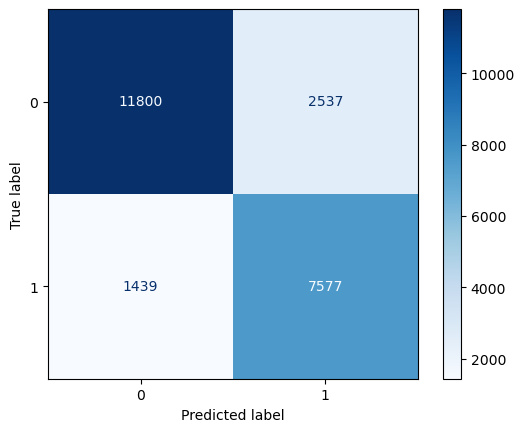

In [34]:
eval_model(model,test_dl)

In [35]:
del model